# 03 — Collective Order and Transport Coupling (Figure 3)

**Question**: Does higher collective order (polarisation) produce faster and more persistent
centroid transport?

## Panels
| Panel | Content |
|-------|---------|
| **A** | Scatter / binned means: polarisation $p(t)$ vs centroid speed $v_c(t)$ |
| **B** | CCDF of run durations split by order tercile (low/mid/high) |
| **C** | CCDF of run lengths split by order tercile |
| **D** | Speed–duration decomposition: $L = T \cdot \bar{v}$ — which drives the length difference? |

**Key result**: High collective order → longer durations **and** higher speeds → longer runs.

**Prerequisite**: Run `01_data_loading.ipynb` first.

In [1]:
import sys, os
from pathlib import Path

_HERE = Path(os.getcwd())
_REPO = _HERE.parents[2]
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from analysis.levy_paper.util.paper_utils import (
    configure_paper_plotting,
    load_cache, save_figure,
    plot_ccdf, plot_ccdf_by_state,
    STATE_COLORS, STATE_LABELS,
)
configure_paper_plotting()

centroid_ord = load_cache("centroid_order_runs")
df_pmv       = load_cache("df_pmv")

centroid_runs = centroid_ord.copy()
print(f"Centroid order runs: {len(centroid_runs):,}")
print(f"Columns: {centroid_runs.columns.tolist()}")

Centroid order runs: 18,021
Columns: ['match_id', 'match_phase', 'team', 'source_key', 'track_type', 'track_entity_uid', 'track_uid', 'run_uid', 'player_name', 'path_uid', 'run_id', 't_start', 't_end', 'duration_s', 'run_length_m', 'v_mean_mps', 'p_start', 'm_start', 'v_group_start', 'p_early_3s', 'm_early_3s', 'v_group_early_3s', 'p_mean', 'p_median', 'm_mean', 'v_group_mean', 'n_pmv_samples', 'p_state', 'p_state_source', 'p_q1', 'p_q2', 'order_state']


## Panel A — Polarisation vs Centroid Speed

Are fast frames also the most polarised?  
We show binned means ± 1 SE to avoid overplotting noise.

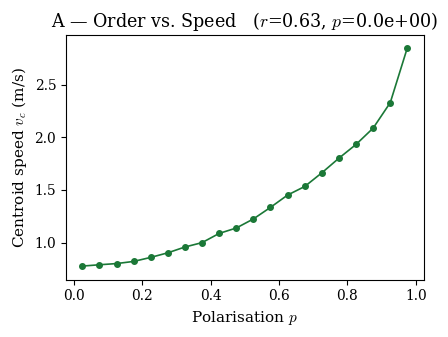

In [2]:
# Use frame-level polarisation × speed from df_pmv
pmv = df_pmv[["p_group", "v_group_mps"]].dropna()

# Bin polarisation into 20 equal-width bins
bins = np.linspace(0, 1, 21)
pmv["p_bin"] = pd.cut(pmv["p_group"], bins=bins)
binned = pmv.groupby("p_bin")["v_group_mps"].agg(["mean", "sem", "count"]).reset_index()
bin_centres = [iv.mid for iv in binned["p_bin"]]

# Pearson correlation
r, pval = stats.pearsonr(pmv["p_group"], pmv["v_group_mps"])

fig_A, ax_A = plt.subplots(figsize=(4.5, 3.5))
ax_A.errorbar(bin_centres, binned["mean"], yerr=binned["sem"],
              fmt="o-", color="#1b7837", ms=4, lw=1.2)
ax_A.set_xlabel("Polarisation $p$")
ax_A.set_ylabel("Centroid speed $v_c$ (m/s)")
ax_A.set_title(f"A — Order vs. Speed   ($r$={r:.2f}, $p$={pval:.1e})")
plt.tight_layout()
plt.show()

## Panels B & C — CCDFs split by order state

We use `p_mean` for the state assignment here (descriptive comparison).
Subsequent hazard modelling (notebook 04) uses `p_start` / `p_early_3s` instead.

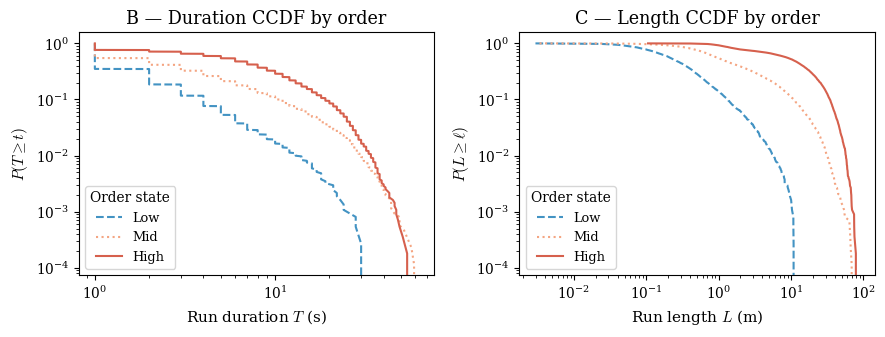

In [3]:
fig_BC, (ax_B, ax_C) = plt.subplots(1, 2, figsize=(9, 3.5))

plot_ccdf_by_state(ax_B, centroid_runs, value_col="duration_s")
ax_B.set_xlabel("Run duration $T$ (s)")
ax_B.set_ylabel(r"$P(T \geq t)$")
ax_B.set_title("B — Duration CCDF by order")

plot_ccdf_by_state(ax_C, centroid_runs, value_col="run_length_m")
ax_C.set_xlabel("Run length $L$ (m)")
ax_C.set_ylabel(r"$P(L \geq \ell)$")
ax_C.set_title("C — Length CCDF by order")

plt.tight_layout()
plt.show()

## Panel D — Speed–Duration Decomposition

Is the longer mean run length in high-order states due to longer duration,
higher speed, or both?  We decompose $\bar{L} = \bar{T} \cdot \bar{v}$.

             duration_s  run_length_m  v_group_mean
order_state                                        
low                 1.0      1.000000      1.000000
mid                 2.0      4.625235      1.843610
high                6.0     42.872077      2.746686


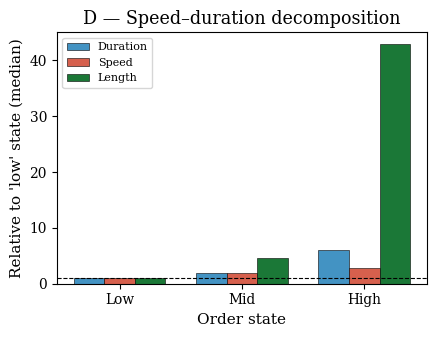

In [4]:
state_summary = (
    centroid_runs
    .groupby("order_state")[["duration_s", "run_length_m", "v_group_mean"]]
    .median()
    .reindex(STATE_LABELS)
)

# Normalise to 'low' state = 1.0
state_norm = state_summary / state_summary.loc["low"]
print(state_norm)

x = np.arange(len(STATE_LABELS))
w = 0.25

fig_D, ax_D = plt.subplots(figsize=(4.5, 3.5))
cols   = {"duration_s": "#4393c3", "v_group_mean": "#d6604d", "run_length_m": "#1b7837"}
labels = {"duration_s": "Duration",  "v_group_mean": "Speed",  "run_length_m": "Length"}

for i, (col, color) in enumerate(cols.items()):
    ax_D.bar(x + (i - 1) * w, state_norm[col].values,
             width=w, color=color, label=labels[col], edgecolor="k", lw=0.4)

ax_D.axhline(1.0, color="k", lw=0.8, ls="--")
ax_D.set_xticks(x)
ax_D.set_xticklabels([s.capitalize() for s in STATE_LABELS])
ax_D.set_xlabel("Order state")
ax_D.set_ylabel("Relative to 'low' state (median)")
ax_D.set_title("D — Speed–duration decomposition")
ax_D.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Assemble and Save Figure 3

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


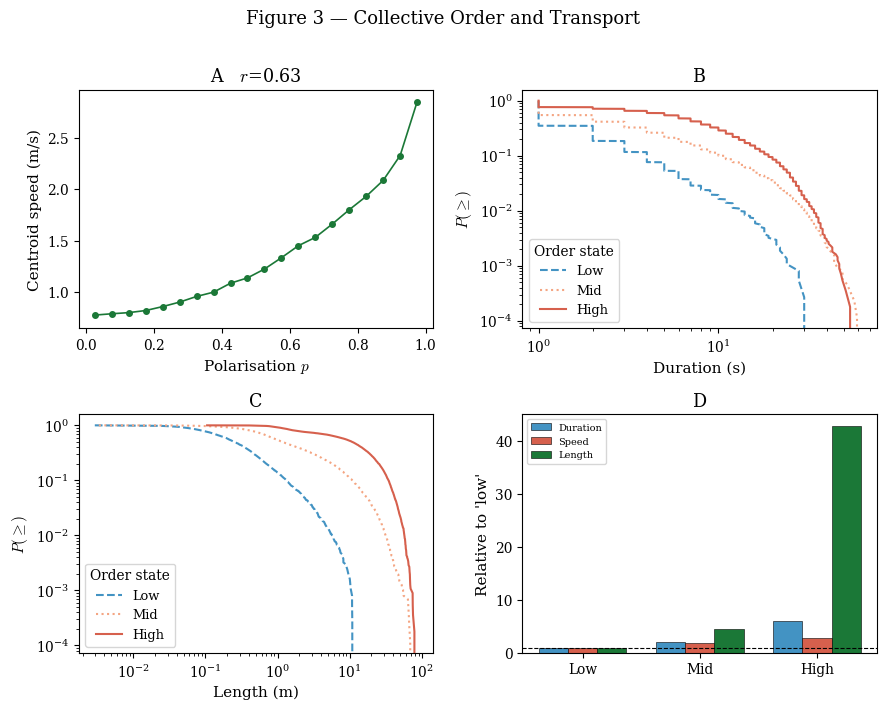

In [5]:
fig3, axes = plt.subplots(2, 2, figsize=(9, 7))
ax_A3, ax_B3, ax_C3, ax_D3 = axes.flat

# A
ax_A3.errorbar(bin_centres, binned["mean"], yerr=binned["sem"],
               fmt="o-", color="#1b7837", ms=4, lw=1.2)
ax_A3.set_xlabel("Polarisation $p$")
ax_A3.set_ylabel("Centroid speed (m/s)")
ax_A3.set_title(f"A   $r$={r:.2f}")

# B
plot_ccdf_by_state(ax_B3, centroid_runs, value_col="duration_s")
ax_B3.set_xlabel("Duration (s)"); ax_B3.set_ylabel(r"$P(\geq)$")
ax_B3.set_title("B")

# C
plot_ccdf_by_state(ax_C3, centroid_runs, value_col="run_length_m")
ax_C3.set_xlabel("Length (m)"); ax_C3.set_ylabel(r"$P(\geq)$")
ax_C3.set_title("C")

# D
for i, (col, color) in enumerate(cols.items()):
    ax_D3.bar(x + (i-1)*w, state_norm[col].values, width=w,
              color=color, label=labels[col], edgecolor="k", lw=0.4)
ax_D3.axhline(1.0, color="k", lw=0.8, ls="--")
ax_D3.set_xticks(x); ax_D3.set_xticklabels([s.capitalize() for s in STATE_LABELS])
ax_D3.set_ylabel("Relative to 'low'"); ax_D3.legend(fontsize=7)
ax_D3.set_title("D")

fig3.suptitle("Figure 3 — Collective Order and Transport", fontsize=13, y=1.01)
save_figure(fig3, "figure3_order_transport")
plt.show()